In [711]:
import matplotlib.pyplot as plt
import numpy as np
import math

import sys
sys.path.append("../../")
from common import *

In [712]:
# градуируем по неоновой лампе
baraban   = [2839, 2192, 2500, 2514, 2546, 2560, 2586, 2606, 2616, 2635, 2644, 2664, 2684, 2702, 2716, 2732, 2740, 2775, 2786, 2811, 2199, 2238] # deg
lambda_Ne = [7032, 5331, 5852, 5882, 5945, 5976, 6030, 6074, 6096, 6143, 6164, 6217, 6267, 6305, 6334, 6383, 6402, 6507, 6533, 6599, 5341, 5401] # angstrem

baraban = baraban[1:]
lambda_Ne = lambda_Ne[1:]

Линейная градуировка - бред

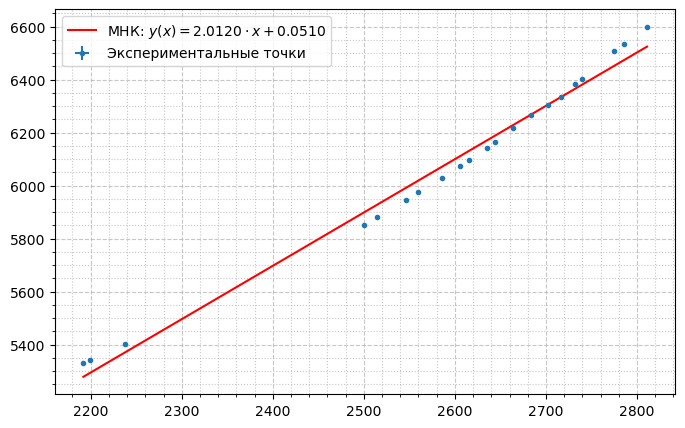

In [713]:
k, b, kerr, berr = linear_graph(baraban, lambda_Ne, [0 for i in range(len(baraban))], [0 for i in range(len(baraban))], "", r"", "")

Полином

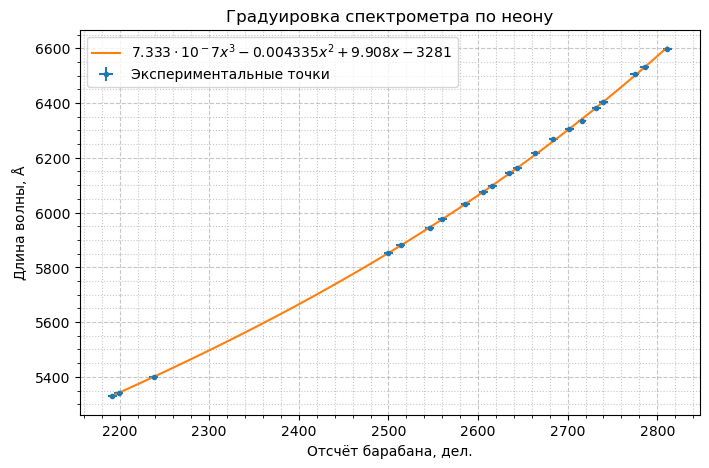

Лучшая степень полинома: 3
Коэффициенты (от старшей степени к свободному члену):
7.332655e-07
-4.335316e-03
9.908481e+00
-3.280507e+03

Итоговый полином калибровки λ(x):
           3            2
7.333e-07 x - 0.004335 x + 9.908 x - 3281


In [714]:
x = np.array(baraban, dtype=float)
y = np.array(lambda_Ne, dtype=float)

xerr = np.full_like(x, 5.0)      # погрешность отсчёта барабана
yerr = np.full_like(y, 5.0)      # эффективная погрешность λ (Å)

degrees = [1, 2, 3]
best = None

for deg in degrees:
    coeffs = np.polyfit(x, y, deg)
    p = np.poly1d(coeffs)
    residuals = y - p(x)
    chi2 = np.sum((residuals / yerr) ** 2)
    k = deg + 1
    n = len(x)
    bic = n * np.log(chi2 / n) + k * np.log(n)
    if best is None or bic < best["bic"]:
        best = {"deg": deg, "coeffs": coeffs, "poly": p, "chi2": chi2, "bic": bic}

calib_poly = best["poly"]

plt.figure(figsize=(8, 5))
plt.errorbar(x, y, xerr=xerr, yerr=yerr, fmt='.', label=r'Экспериментальные точки')
x_fit = np.linspace(x.min(), x.max(), 500)
y_fit = calib_poly(x_fit)
plt.plot(x_fit, y_fit, label=rf'$7.333 \cdot 10^{-7} x^3 - 0.004335 x^2 + 9.908 x - 3281$')

plt.xlabel(r'Отсчёт барабана, дел.')
plt.ylabel(r'Длина волны, $\mathrm{\AA}$')
plt.title(r'Градуировка спектрометра по неону')

plt.minorticks_on()
plt.grid(True, linestyle='--', alpha=0.7, which='major')
plt.grid(True, linestyle=':',  alpha=0.7, which='minor')
plt.legend()
plt.show()

print(f"Лучшая степень полинома: {best['deg']}")
print("Коэффициенты (от старшей степени к свободному члену):")
for c in best["coeffs"]:
    print(f"{c:.6e}")
print("\nИтоговый полином калибровки λ(x):")
print(calib_poly)

In [715]:
d_min_shel = 0.13 # mm
d_shel = 0.1 # mm

In [716]:
deg = 2500 # lambda po barabany
I_0 = 0.014

I = [0.516, 0.505, 0.470, 0.440, 0.390, 0.350, 0.285, 0.330, 0.230, 0.199, 0.170, 0.131, 0.110, 0.090, 0.072, 0.056, 0.039, 0.027, 0.017] # V, по вольтметру верхнему
U = [7.566, 6.962, 5.648, 4.841, 4.144, 3.666, 3.252, 3.318, 2.734, 2.504, 2.284, 1.960, 1.757, 1.541, 1.331, 1.074, 0.775, 0.461, 0.067] # V, по вольтметру нижнему
I = [i - I_0 for i in I]

(<Figure size 800x500 with 1 Axes>, <Axes: >)

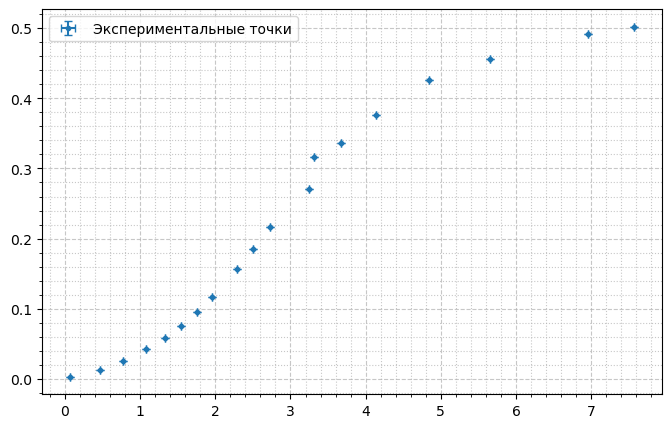

In [717]:
plot(U, I, [0] * len(U), [0] * len(I), "", "", "")

In [718]:
l_volny = 2400 # deg
I_0 = 0
I = [0.027, 0.024, 0.020, 0.019, 0.017, 0.016,  0.015,  0.014,  0.011,  0.009,  0.006,  0.004,  0.002,  0.001]
U = [0.338, 0.266, 0.163, 0.114, 0.067, 0.029, -0.001, -0.036, -0.105, -0.201, -0.279, -0.353, -0.437, -0.490]

I = [i - I_0 for i in I]

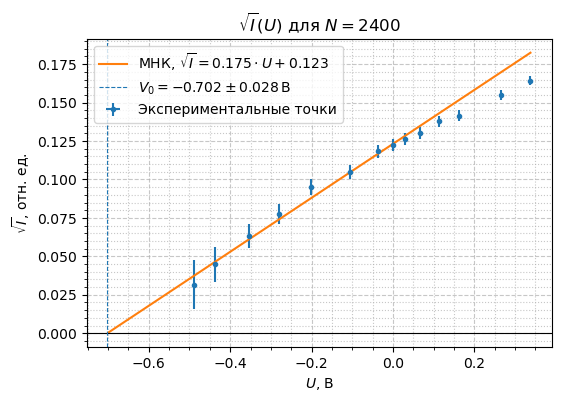

Для N = 2400: V_0 = -0.702 \pm 0.028 В
МНК: k = 0.175 \pm 0.006, b = 0.123 \pm 0.002


In [719]:
I = np.array(I, dtype=float)
U = np.array(U, dtype=float)

# сортировка по убыванию U с сохранением пар (U, I)
idx = np.argsort(U)[::-1]
U = U[idx]
I = I[idx]

U_err = 0.001
I_err = 0.001

mask = I > 0
U_pos = U[mask]
I_pos = I[mask]

sqrtI = np.sqrt(I_pos)
sqrtI_err = 0.5 * I_err / np.sqrt(I_pos)

# точки около запирающего потенциала для линейной аппроксимации
num_fit = 10
num_fit = min(num_fit, len(U_pos))
U_fit = U_pos[-num_fit:]
sqrtI_fit = sqrtI[-num_fit:]

k, b, sigma_k, sigma_b = LeastSquares(U_fit, sqrtI_fit)

V0 = -b / k
dV0 = np.sqrt((b / k**2)**2 * sigma_k**2 + (1 / k)**2 * sigma_b**2)

U_line = np.linspace(-0.7, U_pos.max(), 300)
sqrtI_line = k * U_line + b

plt.figure(figsize=(6, 4))
plt.errorbar(U_pos, sqrtI, xerr=U_err, yerr=sqrtI_err, fmt='.', label=r'Экспериментальные точки')
plt.plot(U_line, sqrtI_line, label=rf'МНК, $\sqrt{{I}} = {k:.3f} \cdot U + {b:.3f}$')
plt.axhline(0, linewidth=0.8, color='k')
plt.axvline(V0, linestyle='--', linewidth=0.8, label=rf'$V_0 = {V0:.3f} \pm {dV0:.3f}\,\mathrm{{В}}$')

plt.xlabel(r'$U$, В')
plt.ylabel(r'$\sqrt{I}$, отн. ед.')
plt.title(rf'$\sqrt{{I}}(U)$ для $N = {l_volny}$')
plt.minorticks_on()
plt.grid(True, linestyle='--', alpha=0.7, which='major')
plt.grid(True, linestyle=':', alpha=0.7, which='minor')
plt.legend()
plt.show()

print(rf'Для N = {l_volny}: V_0 = {V0:.3f} \pm {dV0:.3f} В')
print(rf'МНК: k = {k:.3f} \pm {sigma_k:.3f}, b = {b:.3f} \pm {sigma_b:.3f}')

V_2400 = V0
sigma_V_2400 = dV0


In [720]:
l_volny * k + b

np.float64(421.25512778204285)

In [ ]:
l_volny = 2570 # 2400 # deg
I_0 = 0.046
I = [0.185, 0.155, 0.130, 0.115, 0.100, 0.087, 0.078, 0.102, 0.096, 0.066, 0.050, 0.065, 0.069, 0.067, 0.065, 0.062, 0.060, 0.058, 0.056,  0.055,  0.051,  0.049,  0.047]
U = [2.043, 1.814, 1.613, 1.477, 1.342, 1.189, 1.075, 0.859, 0.792, 0.730, 0.694, 0.638, 0.538, 0.428, 0.327, 0.229, 0.130, 0.027, -0.001 -0.059, -0.147, -0.242, -0.317]

I = [i - I_0 for i in I]

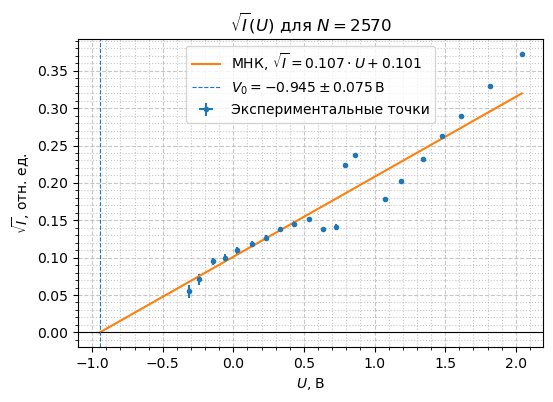

Для N = 2570: V_0 = -0.945 \pm 0.075 В
МНК: k = 0.107 \pm 0.008, b = 0.101 \pm 0.002


In [722]:
I = np.array(I, dtype=float)
U = np.array(U, dtype=float)

# сортировка по убыванию U с сохранением пар (U, I)
idx = np.argsort(U)[::-1]
U = U[idx]
I = I[idx]

U_err = 0.001
I_err = 0.001

mask = I > 0
U_pos = U[mask]
I_pos = I[mask]

sqrtI = np.sqrt(I_pos)
sqrtI_err = 0.5 * I_err / np.sqrt(I_pos)

# точки около запирающего потенциала для линейной аппроксимации
num_fit = 10
num_fit = min(num_fit, len(U_pos))
U_fit = U_pos[-num_fit:]
sqrtI_fit = sqrtI[-num_fit:]

k, b, sigma_k, sigma_b = LeastSquares(U_fit, sqrtI_fit)

V0 = -b / k
dV0 = np.sqrt((b / k**2)**2 * sigma_k**2 + (1 / k)**2 * sigma_b**2)

U_line = np.linspace(-0.95, U_pos.max(), 300)
sqrtI_line = k * U_line + b

plt.figure(figsize=(6, 4))
plt.errorbar(U_pos, sqrtI, xerr=U_err, yerr=sqrtI_err, fmt='.', label=r'Экспериментальные точки')
plt.plot(U_line, sqrtI_line, label=rf'МНК, $\sqrt{{I}} = {k:.3f} \cdot U + {b:.3f}$')
plt.axhline(0, linewidth=0.8, color='k')
plt.axvline(V0, linestyle='--', linewidth=0.8, label=rf'$V_0 = {V0:.3f} \pm {dV0:.3f}\,\mathrm{{В}}$')

plt.xlabel(r'$U$, В')
plt.ylabel(r'$\sqrt{I}$, отн. ед.')
plt.title(rf'$\sqrt{{I}}(U)$ для $N = {l_volny}$')
plt.minorticks_on()
plt.grid(True, linestyle='--', alpha=0.7, which='major')
plt.grid(True, linestyle=':', alpha=0.7, which='minor')
plt.legend()
plt.show()

print(rf'Для N = {l_volny}: V_0 = {V0:.3f} \pm {dV0:.3f} В')
print(rf'МНК: k = {k:.3f} \pm {sigma_k:.3f}, b = {b:.3f} \pm {sigma_b:.3f}')

V_2570 = V0
sigma_V_2570 = dV0

верхние 2 измерения возможно перепутаны l_volny

In [723]:
l_volny = 2740 # deg
I_0 = 0.000
I = [0.082, 0.062, 0.052, 0.045, 0.038, 0.031, 0.026, 0.021, 0.016, 0.013, 0.012,  0.010,  0.008,  0.005,  0.003,  0.001]
U = [0.979, 0.825, 0.714, 0.615, 0.521, 0.420, 0.320, 0.222, 0.120, 0.055, 0.027, -0.007, -0.051, -0.100, -0.153, -0.201]

I = [i - I_0 for i in I]

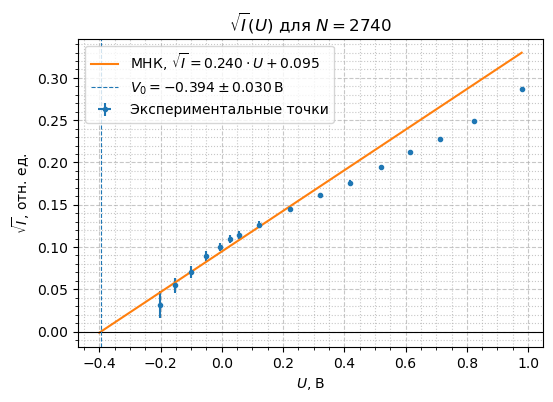

Для N = 2740: V_0 = -0.394 \pm 0.030 В
МНК: k = 0.240 \pm 0.017, b = 0.095 \pm 0.003


In [724]:
I = np.array(I, dtype=float)
U = np.array(U, dtype=float)

# сортировка по убыванию U с сохранением пар (U, I)
idx = np.argsort(U)[::-1]
U = U[idx]
I = I[idx]

U_err = 0.001
I_err = 0.001

mask = I > 0
U_pos = U[mask]
I_pos = I[mask]

sqrtI = np.sqrt(I_pos)
sqrtI_err = 0.5 * I_err / np.sqrt(I_pos)

# точки около запирающего потенциала для линейной аппроксимации
num_fit = 10
num_fit = min(num_fit, len(U_pos))
U_fit = U_pos[-num_fit:]
sqrtI_fit = sqrtI[-num_fit:]

k, b, sigma_k, sigma_b = LeastSquares(U_fit, sqrtI_fit)

V0 = -b / k
dV0 = np.sqrt((b / k**2)**2 * sigma_k**2 + (1 / k)**2 * sigma_b**2)

U_line = np.linspace(-0.4, U_pos.max(), 300)
sqrtI_line = k * U_line + b

plt.figure(figsize=(6, 4))
plt.errorbar(U_pos, sqrtI, xerr=U_err, yerr=sqrtI_err, fmt='.', label=r'Экспериментальные точки')
plt.plot(U_line, sqrtI_line, label=rf'МНК, $\sqrt{{I}} = {k:.3f} \cdot U + {b:.3f}$')
plt.axhline(0, linewidth=0.8, color='k')
plt.axvline(V0, linestyle='--', linewidth=0.8, label=rf'$V_0 = {V0:.3f} \pm {dV0:.3f}\,\mathrm{{В}}$')

plt.xlabel(r'$U$, В')
plt.ylabel(r'$\sqrt{I}$, отн. ед.')
plt.title(rf'$\sqrt{{I}}(U)$ для $N = {l_volny}$')
plt.minorticks_on()
plt.grid(True, linestyle='--', alpha=0.7, which='major')
plt.grid(True, linestyle=':', alpha=0.7, which='minor')
plt.legend()
plt.show()

print(rf'Для N = {l_volny}: V_0 = {V0:.3f} \pm {dV0:.3f} В')
print(rf'МНК: k = {k:.3f} \pm {sigma_k:.3f}, b = {b:.3f} \pm {sigma_b:.3f}')

V_2740 = V0
sigma_V_2740 = dV0

In [725]:
l_volny = 2800 # deg
I_0 = 0.000
I = [0.063, 0.052, 0.042, 0.034, 0.028, 0.023, 0.018, 0.013, 0.012, 0.011,  0.008,  0.006,  0.004,  0.001]
U = [0.804, 0.703, 0.591, 0.488, 0.399, 0.301, 0.199, 0.103, 0.048, 0.027, -0.004, -0.051, -0.100, -0.149]

I = [i - I_0 for i in I]

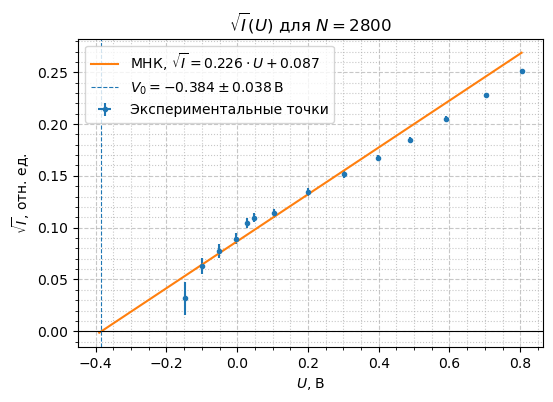

Для N = 2800: V_0 = -0.384 \pm 0.038 В
МНК: k = 0.226 \pm 0.020, b = 0.087 \pm 0.004


In [726]:
I = np.array(I, dtype=float)
U = np.array(U, dtype=float)

# сортировка по убыванию U с сохранением пар (U, I)
idx = np.argsort(U)[::-1]
U = U[idx]
I = I[idx]

U_err = 0.001
I_err = 0.001

mask = I > 0
U_pos = U[mask]
I_pos = I[mask]

sqrtI = np.sqrt(I_pos)
sqrtI_err = 0.5 * I_err / np.sqrt(I_pos)

# точки около запирающего потенциала для линейной аппроксимации
num_fit = 10
num_fit = min(num_fit, len(U_pos))
U_fit = U_pos[-num_fit:]
sqrtI_fit = sqrtI[-num_fit:]

k, b, sigma_k, sigma_b = LeastSquares(U_fit, sqrtI_fit)

V0 = -b / k
dV0 = np.sqrt((b / k**2)**2 * sigma_k**2 + (1 / k)**2 * sigma_b**2)

U_line = np.linspace(-0.39, U_pos.max(), 300)
sqrtI_line = k * U_line + b

plt.figure(figsize=(6, 4))
plt.errorbar(U_pos, sqrtI, xerr=U_err, yerr=sqrtI_err, fmt='.', label=r'Экспериментальные точки')
plt.plot(U_line, sqrtI_line, label=rf'МНК, $\sqrt{{I}} = {k:.3f} \cdot U + {b:.3f}$')
plt.axhline(0, linewidth=0.8, color='k')
plt.axvline(V0, linestyle='--', linewidth=0.8, label=rf'$V_0 = {V0:.3f} \pm {dV0:.3f}\,\mathrm{{В}}$')

plt.xlabel(r'$U$, В')
plt.ylabel(r'$\sqrt{I}$, отн. ед.')
plt.title(rf'$\sqrt{{I}}(U)$ для $N = {l_volny}$')
plt.minorticks_on()
plt.grid(True, linestyle='--', alpha=0.7, which='major')
plt.grid(True, linestyle=':', alpha=0.7, which='minor')
plt.legend()
plt.show()

print(rf'Для N = {l_volny}: V_0 = {V0:.3f} \pm {dV0:.3f} В')
print(rf'МНК: k = {k:.3f} \pm {sigma_k:.3f}, b = {b:.3f} \pm {sigma_b:.3f}')

V_2800 = V0
sigma_V_2800 = dV0

In [727]:
l_volny = 2650 # deg
I_0 = -0.003 # (-0.008 + 0.002) / 2
I = [0.054, 0.045, 0.039, 0.032, 0.027, 0.022, 0.018, 0.017, 0.016,  0.012,  0.011,  0.008,  0.005,  0.002,  0.001]
U = [0.706, 0.605, 0.501, 0.404, 0.299, 0.203, 0.101, 0.048, 0.027, -0.034, -0.070, -0.150, -0.214, -0.302, -0.350]

I = [i - I_0 for i in I]

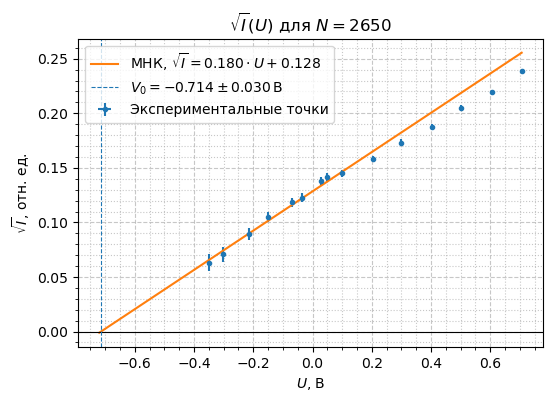

Для N = 2650: V_0 = -0.714 \pm 0.030 В
МНК: k = 0.180 \pm 0.007, b = 0.128 \pm 0.001


In [728]:
I = np.array(I, dtype=float)
U = np.array(U, dtype=float)

# сортировка по убыванию U с сохранением пар (U, I)
idx = np.argsort(U)[::-1]
U = U[idx]
I = I[idx]

U_err = 0.001
I_err = 0.001

mask = I > 0
U_pos = U[mask]
I_pos = I[mask]

sqrtI = np.sqrt(I_pos)
sqrtI_err = 0.5 * I_err / np.sqrt(I_pos)

# точки около запирающего потенциала для линейной аппроксимации
num_fit = 10
num_fit = min(num_fit, len(U_pos))
U_fit = U_pos[-num_fit:]
sqrtI_fit = sqrtI[-num_fit:]

k, b, sigma_k, sigma_b = LeastSquares(U_fit, sqrtI_fit)

V0 = -b / k
dV0 = np.sqrt((b / k**2)**2 * sigma_k**2 + (1 / k)**2 * sigma_b**2)

U_line = np.linspace(-0.72, U_pos.max(), 300)
sqrtI_line = k * U_line + b

plt.figure(figsize=(6, 4))
plt.errorbar(U_pos, sqrtI, xerr=U_err, yerr=sqrtI_err, fmt='.', label=r'Экспериментальные точки')
plt.plot(U_line, sqrtI_line, label=rf'МНК, $\sqrt{{I}} = {k:.3f} \cdot U + {b:.3f}$')
plt.axhline(0, linewidth=0.8, color='k')
plt.axvline(V0, linestyle='--', linewidth=0.8, label=rf'$V_0 = {V0:.3f} \pm {dV0:.3f}\,\mathrm{{В}}$')

plt.xlabel(r'$U$, В')
plt.ylabel(r'$\sqrt{I}$, отн. ед.')
plt.title(rf'$\sqrt{{I}}(U)$ для $N = {l_volny}$')
plt.minorticks_on()
plt.grid(True, linestyle='--', alpha=0.7, which='major')
plt.grid(True, linestyle=':', alpha=0.7, which='minor')
plt.legend()
plt.show()

print(rf'Для N = {l_volny}: V_0 = {V0:.3f} \pm {dV0:.3f} В')
print(rf'МНК: k = {k:.3f} \pm {sigma_k:.3f}, b = {b:.3f} \pm {sigma_b:.3f}')

V_2650 = V0
sigma_V_2650 = dV0

In [729]:
l_volny = 2350 # deg
I_0 = 0.001
I = [0.049, 0.039, 0.034, 0.029, 0.025, 0.022, 0.018, 0.017,  0.014,  0.012,  0.009,  0.006,  0.003,  0.000]
U = [0.700, 0.600, 0.499, 0.400, 0.300, 0.200, 0.101, 0.051, -0.002, -0.100, -0.201, -0.303, -0.402, -0.500]

I = [i - I_0 for i in I]

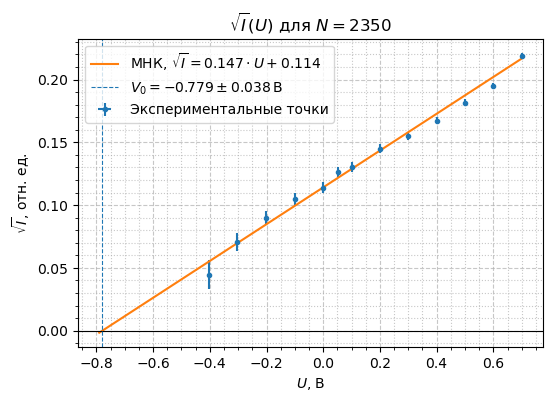

Для N = 2350: V_0 = -0.779 \pm 0.038 В
МНК: k = 0.147 \pm 0.007, b = 0.114 \pm 0.002


In [730]:
I = np.array(I, dtype=float)
U = np.array(U, dtype=float)

# сортировка по убыванию U с сохранением пар (U, I)
idx = np.argsort(U)[::-1]
U = U[idx]
I = I[idx]

U_err = 0.001
I_err = 0.001

mask = I > 0
U_pos = U[mask]
I_pos = I[mask]

sqrtI = np.sqrt(I_pos)
sqrtI_err = 0.5 * I_err / np.sqrt(I_pos)

# точки около запирающего потенциала для линейной аппроксимации
num_fit = 10
num_fit = min(num_fit, len(U_pos))
U_fit = U_pos[-num_fit:]
sqrtI_fit = sqrtI[-num_fit:]

k, b, sigma_k, sigma_b = LeastSquares(U_fit, sqrtI_fit)

V0 = -b / k
dV0 = np.sqrt((b / k**2)**2 * sigma_k**2 + (1 / k)**2 * sigma_b**2)

U_line = np.linspace(-0.79, U_pos.max(), 300)
sqrtI_line = k * U_line + b

plt.figure(figsize=(6, 4))
plt.errorbar(U_pos, sqrtI, xerr=U_err, yerr=sqrtI_err, fmt='.', label=r'Экспериментальные точки')
plt.plot(U_line, sqrtI_line, label=rf'МНК, $\sqrt{{I}} = {k:.3f} \cdot U + {b:.3f}$')
plt.axhline(0, linewidth=0.8, color='k')
plt.axvline(V0, linestyle='--', linewidth=0.8, label=rf'$V_0 = {V0:.3f} \pm {dV0:.3f}\,\mathrm{{В}}$')

plt.xlabel(r'$U$, В')
plt.ylabel(r'$\sqrt{I}$, отн. ед.')
plt.title(rf'$\sqrt{{I}}(U)$ для $N = {l_volny}$')
plt.minorticks_on()
plt.grid(True, linestyle='--', alpha=0.7, which='major')
plt.grid(True, linestyle=':', alpha=0.7, which='minor')
plt.legend()
plt.show()

print(rf'Для N = {l_volny}: V_0 = {V0:.3f} \pm {dV0:.3f} В')
print(rf'МНК: k = {k:.3f} \pm {sigma_k:.3f}, b = {b:.3f} \pm {sigma_b:.3f}')

V_2350 = V0
sigma_V_2350 = dV0

In [731]:
l_volny = 2900 # deg
I_0 = 0.001
I = [0.037, 0.027, 0.020, 0.014, 0.010, 0.007,  0.004,  0.002,  0.001] # V
U = [0.500, 0.403, 0.298, 0.197, 0.100, 0.027, -0.024, -0.076, -0.120] # V

I = [i - I_0 for i in I]

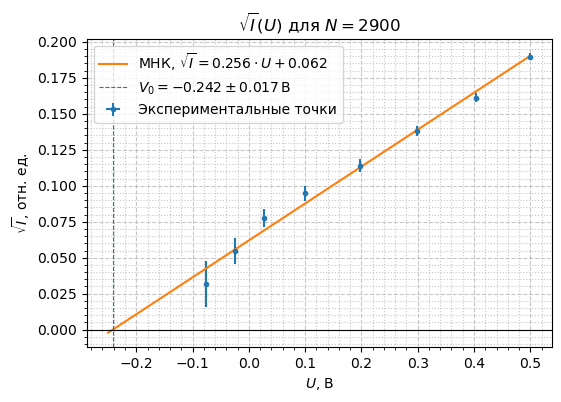

Для N = 2900: V_0 = -0.242 \pm 0.017 В
МНК: k = 0.256 \pm 0.012, b = 0.062 \pm 0.003


In [732]:
I = np.array(I, dtype=float)
U = np.array(U, dtype=float)

# сортировка по убыванию U с сохранением пар (U, I)
idx = np.argsort(U)[::-1]
U = U[idx]
I = I[idx]

U_err = 0.001
I_err = 0.001

mask = I > 0
U_pos = U[mask]
I_pos = I[mask]

sqrtI = np.sqrt(I_pos)
sqrtI_err = 0.5 * I_err / np.sqrt(I_pos)

# точки около запирающего потенциала для линейной аппроксимации
num_fit = 10
num_fit = min(num_fit, len(U_pos))
U_fit = U_pos[-num_fit:]
sqrtI_fit = sqrtI[-num_fit:]

k, b, sigma_k, sigma_b = LeastSquares(U_fit, sqrtI_fit)

V0 = -b / k
dV0 = np.sqrt((b / k**2)**2 * sigma_k**2 + (1 / k)**2 * sigma_b**2)

U_line = np.linspace(-0.25, U_pos.max(), 300)
sqrtI_line = k * U_line + b

plt.figure(figsize=(6, 4))
plt.errorbar(U_pos, sqrtI, xerr=U_err, yerr=sqrtI_err, fmt='.', label=r'Экспериментальные точки')
plt.plot(U_line, sqrtI_line, label=rf'МНК, $\sqrt{{I}} = {k:.3f} \cdot U + {b:.3f}$')
plt.axhline(0, linewidth=0.8, color='k')
plt.axvline(V0, linestyle='--', linewidth=0.8, label=rf'$V_0 = {V0:.3f} \pm {dV0:.3f}\,\mathrm{{В}}$')

plt.xlabel(r'$U$, В')
plt.ylabel(r'$\sqrt{I}$, отн. ед.')
plt.title(rf'$\sqrt{{I}}(U)$ для $N = {l_volny}$')
plt.minorticks_on()
plt.grid(True, linestyle='--', alpha=0.7, which='major')
plt.grid(True, linestyle=':', alpha=0.7, which='minor')
plt.legend()
plt.show()

print(rf'Для N = {l_volny}: V_0 = {V0:.3f} \pm {dV0:.3f} В')
print(rf'МНК: k = {k:.3f} \pm {sigma_k:.3f}, b = {b:.3f} \pm {sigma_b:.3f}')

V_2900 = V0
sigma_V_2900 = dV0